In [1]:
import random
import numpy as np
from closest_masses import best_cost, subset_sum_max_cost
import tqdm

eps = 1e-4


def gen_random_masses(n, seed):
    random.seed(seed)
    l = [random.random() for _ in range(n)]
    s = sum(l)
    return [x / s for x in l]



## Case of one flow going in and one going out

$cos(\theta) \le \frac{(m-M)^{2\alpha} - m^{2\alpha} - M^{2\alpha}}{2(mM)^{\alpha}}$

The minimum is achieved when $M = 1$ and $m$ is the smallest possible value.

In [4]:
# collect data for every alpha 

data = []
max_n = 100
alphas = np.array([.05, .1, .2, .3, .5, .7, .9, .99])
ns = range(2, max_n, max_n//20)

for alpha in alphas:
    for n in ns:
        for seed in range(50):
            masses = gen_random_masses(n, seed)
            m = min(masses)
            M = 1
            cos_theta = (M - m) ** (2 * alpha) - m ** (2 * alpha) - M ** (2 * alpha)
            cos_theta /= 2 * (m * M) ** alpha
            data.append((n, alpha, cos_theta))



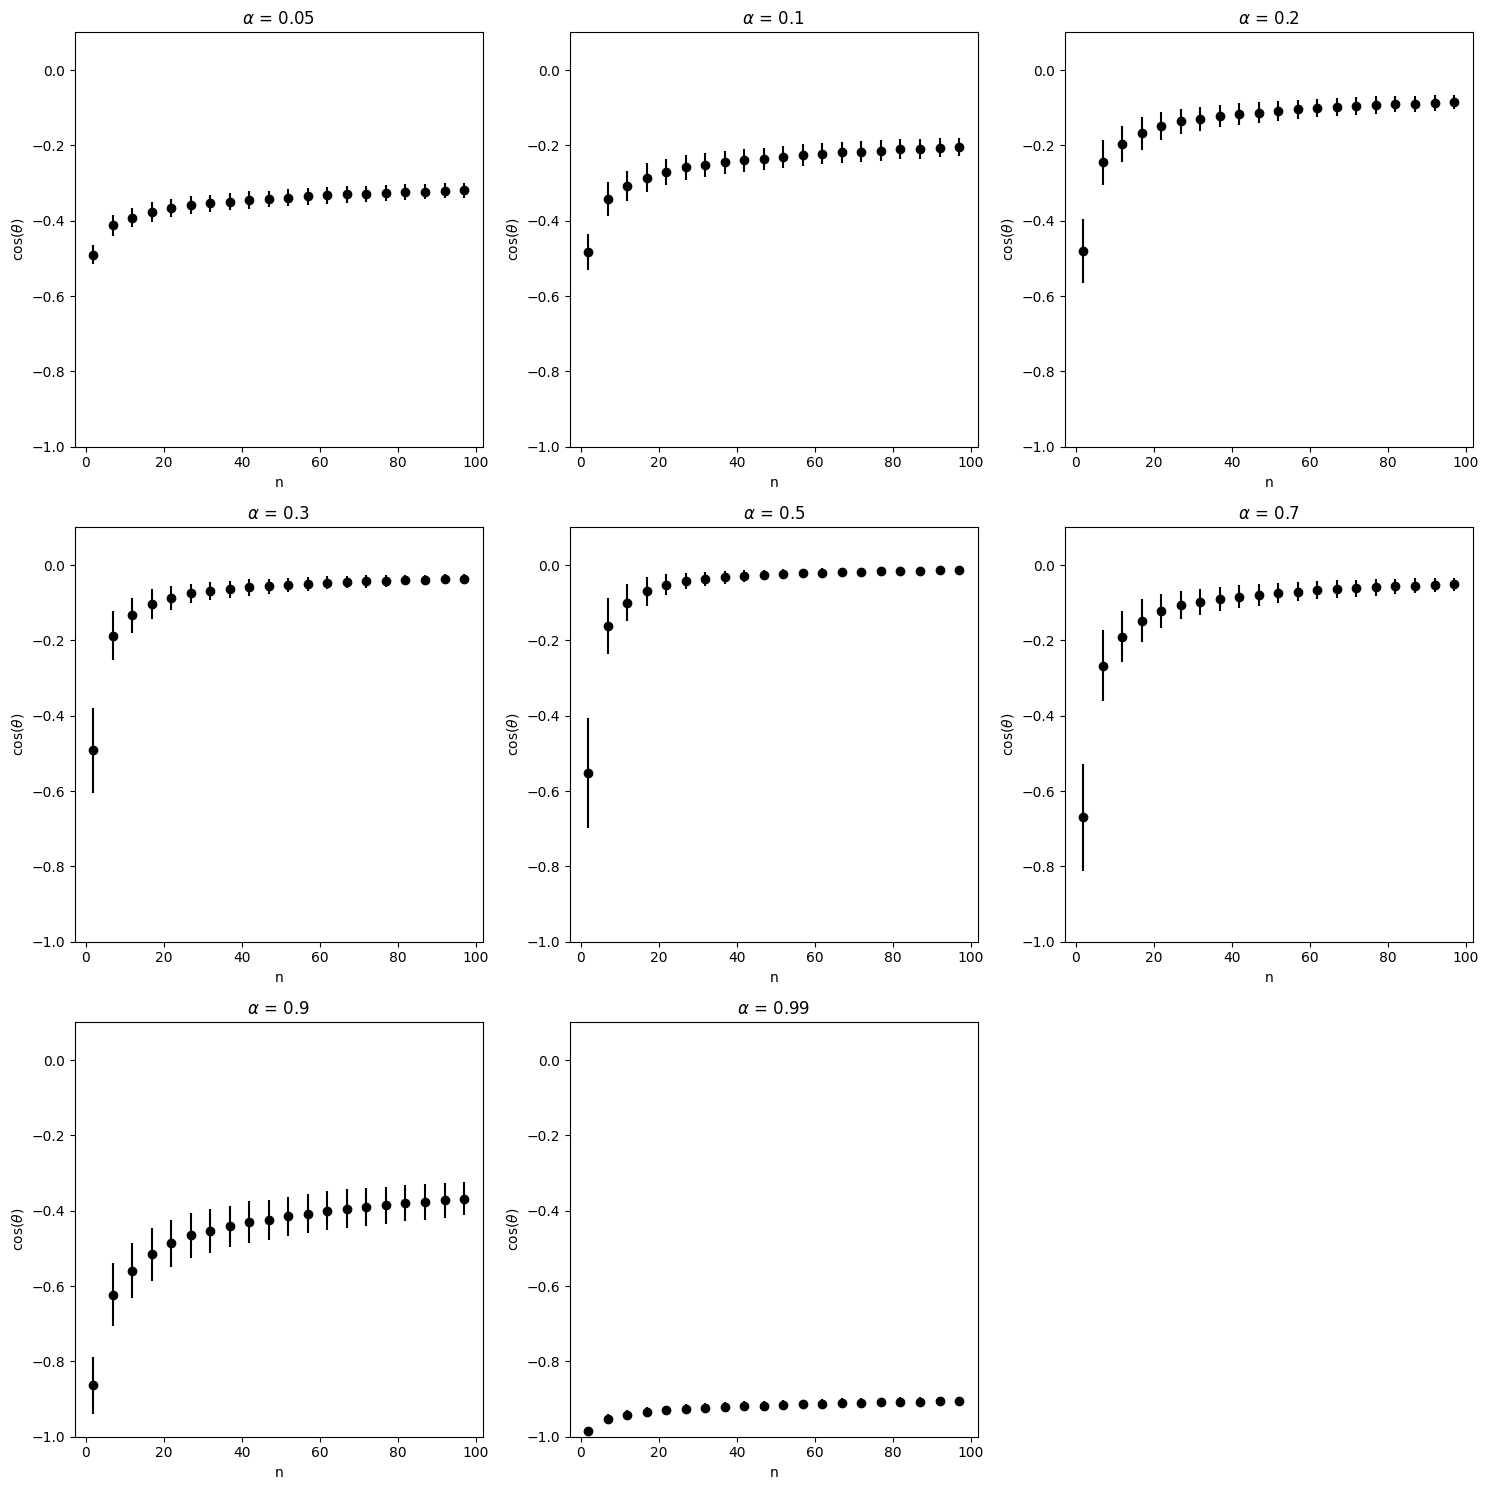

In [5]:
import matplotlib.pyplot as plt

data = np.array(data)
alphas = np.array(alphas)

# Define grid dimensions (adjust this based on the number of alphas)
n_cols = 3  # Number of columns for the grid
n_rows = int(np.ceil(len(alphas) / n_cols))  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten the axes array to easily index

for i, alpha in enumerate(alphas):
    ax = axes[i]
    ax.set_title(rf"$\alpha$ = {round(alpha, 2)}")

    for n in ns:
        mask = data[:, 0] == n
        mask &= data[:, 1] == alpha
        cos_theta = data[mask, 2]
        if len(cos_theta) > 0:
            ax.errorbar(n, np.mean(cos_theta), yerr=np.std(cos_theta), fmt='o', color='black')
            # plot horizontal line at max(2**(2*alpha - 1) - 1, 0) # todo: this is NOT the best value
            # ax.axhline(max(2**(2*alpha - 1) - 1, 0), color='red', linestyle='--')

    ax.set_xlabel("n")
    ax.set_ylabel(r"$\cos(\theta)$")

# Remove empty subplots (if any)
for i in range(len(alphas), len(axes)):
    fig.delaxes(axes[i])

# fix scale of y axis for all
for ax in axes:
    ax.set_ylim(-1, .1)
    # pass

plt.tight_layout()  # Adjusts layout so everything fits without overlap
plt.show()

## Case of two flows going out
$\cos(\theta) \le \frac{(m+M)^{2\alpha} - m^{2\alpha} - M^{2\alpha}}{2(mM)^{\alpha}}$

In [7]:
# collect data for every alpha 

data = []
ns = range(2, 100, 1)

for alpha in tqdm.tqdm(alphas):
    for n in ns:
        if alpha > .5 and n > 8:
            continue
        for seed in range(50):
            masses = gen_random_masses(n, seed)
            if alpha > .5:
                best_comb, cos_theta, _ = subset_sum_max_cost(masses, alpha)
            else:
                m = min(masses)
                M = sum(masses) - m
                cos_theta = (M + m) ** (2 * alpha) - m ** (2 * alpha) - M ** (2 * alpha)
                cos_theta /= 2 * (m * M) ** alpha

            data.append((n, alpha, cos_theta))

100%|██████████| 8/8 [00:02<00:00,  3.40it/s]


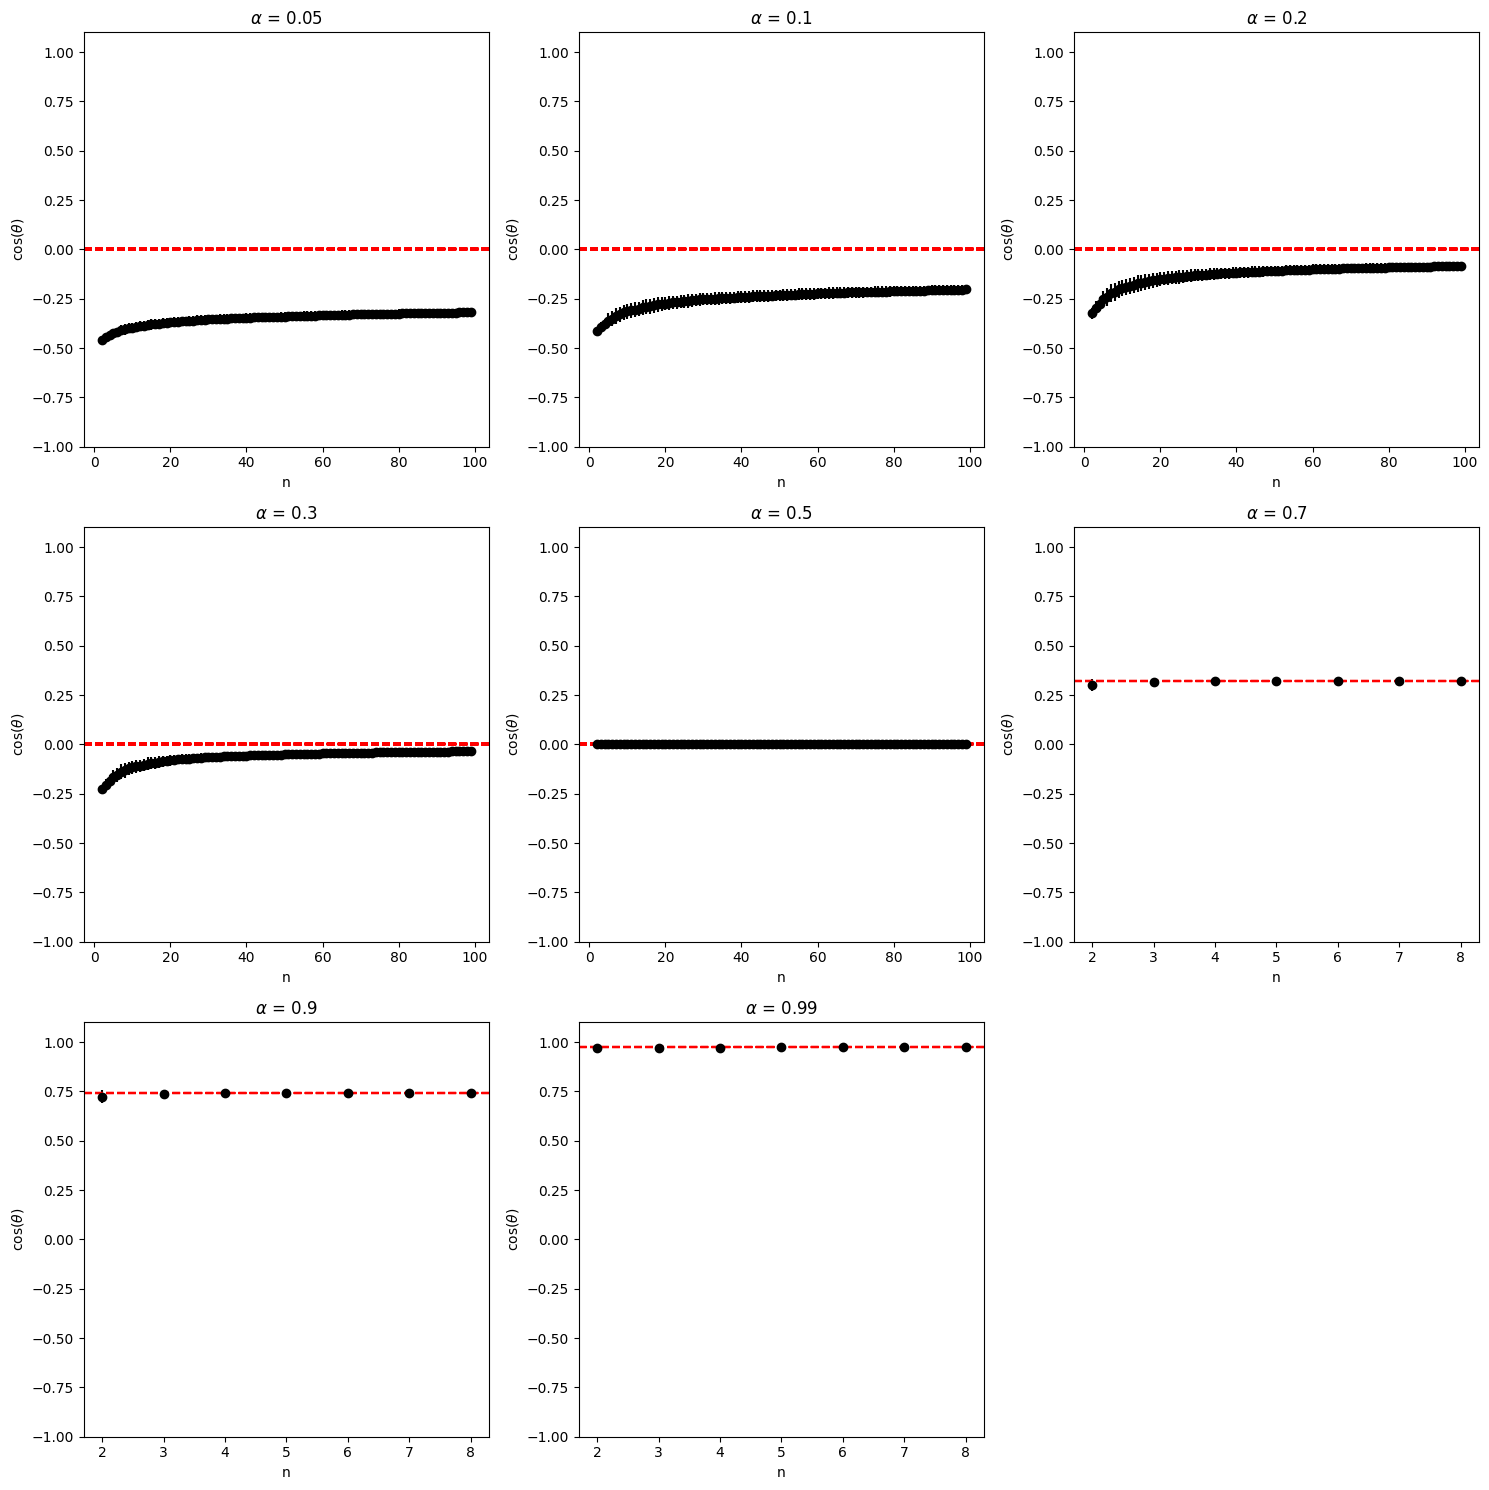

In [8]:
import matplotlib.pyplot as plt

data = np.array(data)
alphas = np.array(alphas)

# Define grid dimensions (adjust this based on the number of alphas)
n_cols = 3  # Number of columns for the grid
n_rows = int(np.ceil(len(alphas) / n_cols))  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten the axes array to easily index

for i, alpha in enumerate(alphas):
    ax = axes[i]
    ax.set_title(rf"$\alpha$ = {round(alpha, 2)}")

    for n in ns:

        mask = data[:, 0] == n
        mask &= data[:, 1] == alpha
        cos_theta = data[mask, 2]
        if len(cos_theta) > 0:
            ax.errorbar(n, np.mean(cos_theta), yerr=np.std(cos_theta), fmt='o', color='black')
            # plot horizontal line at max(2**(2*alpha - 1) - 1, 0)
            ax.axhline(max(2 ** (2 * alpha - 1) - 1, 0), color='red', linestyle='--')

    ax.set_xlabel("n")
    ax.set_ylabel(r"$\cos(\theta)$")

# Remove empty subplots (if any)
for i in range(len(alphas), len(axes)):
    fig.delaxes(axes[i])

# fix scale of y axis for all
for ax in axes:
    ax.set_ylim(-1, 1.1)

plt.tight_layout()  # Adjusts layout so everything fits without overlap
plt.show()

As we can see for $\alpha > 1/2$ it is very easy to achieve almost optimal results (so $m_1 \approx m_2$)